In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path("dati_schede_min.csv")
GEOJSON_PATH = Path("lat_long_23.json")

CSV_ID_COLUMN = "id_scheda_originale"
GEOJSON_ID_PROPERTY = "ID"

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

print("CSV:", CSV_PATH)
print("GeoJSON:", GEOJSON_PATH)


CSV: dati_schede_23.csv
GeoJSON: lat_long_23.json


In [4]:
# Load the two files
csv_df = pd.read_csv(CSV_PATH, low_memory=False)

with GEOJSON_PATH.open("r", encoding="utf-8") as file:
    geojson = json.load(file)

features = geojson.get("features", [])

geo_rows = []
for index, feature in enumerate(features):
    geometry = feature.get("geometry") or {}
    properties = feature.get("properties") or {}
    coordinates = geometry.get("coordinates")

    geo_rows.append({
        "_feature_index": index,
        "_geometry_type": geometry.get("type"),
        "_coordinates": coordinates,
        **properties,
    })

geo_df = pd.DataFrame(geo_rows)

print(f"CSV loaded: {len(csv_df):,} rows × {csv_df.shape[1]:,} columns")
print(f"GeoJSON loaded: {len(features):,} features")


CSV loaded: 29,575 rows × 243 columns
GeoJSON loaded: 29,575 features


## 1. Basic file characteristics

In [5]:
def file_characteristics(path):
    stat = path.stat()
    return {
        "file": path.name,
        "size_bytes": stat.st_size,
        "size_mb": stat.st_size / 1024**2,
        "suffix": path.suffix,
    }

file_summary = pd.DataFrame([
    file_characteristics(CSV_PATH),
    file_characteristics(GEOJSON_PATH),
])

display(file_summary)

print("\nGeoJSON top-level type:", geojson.get("type"))
print("GeoJSON top-level keys:", list(geojson.keys()))
print("CSV shape:", csv_df.shape)
print("GeoJSON table shape:", geo_df.shape)


,file,size_bytes,size_mb,suffix
0,dati_schede_23.csv,100018894,95.385450,.csv
1,lat_long_23.json,11138864,10.622849,.json



GeoJSON top-level type: FeatureCollection
GeoJSON top-level keys: ['type', 'features']
CSV shape: (29575, 243)
GeoJSON table shape: (29575, 9)


## 2. CSV inspection

In [6]:
print("CSV columns:")
display(pd.DataFrame({
    "column": csv_df.columns,
    "dtype": csv_df.dtypes.astype(str).values,
    "non_null": csv_df.notna().sum().values,
    "missing": csv_df.isna().sum().values,
    "missing_percent": (csv_df.isna().mean().values * 100).round(2),
}).head(50))

print(f"\nTotal CSV columns: {csv_df.shape[1]:,}")
display(csv_df.head())


CSV columns:


,column,dtype,non_null,missing,missing_percent
0,id_scheda_originale,str,29575,0,0.00
1,cdidentificazione__tsktipo_scheda,str,28843,732,2.48
2,cdidentificazione__lirlivello_catalogazione,str,28843,732,2.48
3,nctcodice_univoco_iccd__nctrcodice_regione,float64,28843,732,2.48
4,nctcodice_univoco_iccd__nctnnumero_catalogo_generale,float64,28843,732,2.48
5,nctcodice_univoco_iccd__escente_schedatore,str,28843,732,2.48
6,nctcodice_univoco_iccd__ecpente_competente_per_tutela,str,28843,732,2.48
7,ogdefinizione_denominazione__ambambito_di_tutela_mic,str,28843,732,2.48
8,ogdefinizione_denominazione__ctgcategoria,str,28843,732,2.48
9,ogdefinizione_denominazione__ogtdefinizione_tipologica,str,28843,732,2.48



Total CSV columns: 243


,id_scheda_originale,cdidentificazione__tsktipo_scheda,cdidentificazione__lirlivello_catalogazione,nctcodice_univoco_iccd__nctrcodice_regione,nctcodice_univoco_iccd__nctnnumero_catalogo_generale,nctcodice_univoco_iccd__escente_schedatore,nctcodice_univoco_iccd__ecpente_competente_per_tutela,ogdefinizione_denominazione__ambambito_di_tutela_mic,ogdefinizione_denominazione__ctgcategoria,ogdefinizione_denominazione__ogtdefinizione_tipologica,ogdefinizione_denominazione__ogunumero_spazi,lclocalizzazione__lcrregione,lclocalizzazione__lcpprovincia,lclocalizzazione__lcccomune,acbaccessibilità_del_bene__acbaaccessibilità,acbaccessibilità_del_bene__acblspecifiche,ctsidentificativi_catastali__ctsccomune_catastale,ctsidentificativi_catastali__ctsttipo_catasto,ctsidentificativi_catastali__ctsffoglio,gegeoreferenziazione__geltipo_di_localizzazione,gegeoreferenziazione__gettipo_di_georeferenziazione,gegeoreferenziazione__gepsistema_di_riferimento,gpbbase_cartografica__gpbbdescrizione_sintetica,cacontesto_ambientale_naturale_paesaggistico__cabcontesto_paesaggistico_(sintesi),cacontesto_ambientale_naturale_paesaggistico__caaquadro_attuale,...,rserelazioni_con_altri_beni_catalogati__rezspecifiche_sulle_relazioni,aszrecinzioni__asznnote,accaltro_codice__accpprogetto,prepreesistenze__prepposizione,prepreesistenze__precriferimento_cronologico,ctsidentificativi_catastali__cteelementi_confinanti,pvlaltro_toponimo__pvlsnote,asppavimentazioni__aspqquantità,accaltro_codice__accrriferimento_cronologico,accaltro_codice__accsnote,iqainquinamento_ambientale__iqattipo,iqainquinamento_ambientale__iqaddescrizione_della_situazione,ctsidentificativi_catastali__ctspproprietari,tucondizione_giuridica__nvcprovvedimenti_amministrativi-specifiche,asrspazio__asrldefinizione_tipologica_locale,tucondizione_giuridica__cdscondizione_giuridica_specifiche,accaltro_codice__accwindirizzo_web,prepreesistenze__preedenominazione,prepreesistenze__nscnotizie_storico_critiche,prepreesistenze__naiconsiderazioni_sugli_aspetti_di_interesse,prepreesistenze__prennote,csdati_catastali__cteelementi_confinanti,gpbbase_cartografica__gpbuindirizzo_web_(url),csdati_catastali__ctnnote,gegeoreferenziazione__gennote
0,ce9c9265-54dd-4779-9c4b-cc282dc908e3,AR,P,6.0,182407.0,ICCD,S239,architettonico e paesaggistico,EDIFICIO SINGOLO,casa con loggiato,nr,Friuli-Venezia Giulia,UD,Dignano,no,non è stato possibile accedere alla proprietà,D300,Catasto misto,17,localizzazione fisica,georeferenziazione areale,WGS84,OSM,pianura,"Dal punto di vista geomorfologico, il territorio su cui insiste l’edificio, ricade nell’alta pianura friulana e ison...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6e02ff7c-2b9d-40d0-a14c-e8f4d03d9a83,AR,I,20.0,252733.0,ICCD,S252,architettonico e paesaggistico,EDIFICIO SINGOLO,casa a corte chiusa,nr,Sardegna,SU,Soleminis,no,non è stato possibile accedere alla proprietà,I797,Catasto misto,17,localizzazione fisica,georeferenziazione areale,WGS84,OSM,collina,"Edificio abitativo a corte interna con annesso, posto all'interno dell'area individuata dal PPR come ""Centro di anti...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6f0c5f37-e427-477b-a3e7-f151ae6da631,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,50d167e2-614a-4fc1-bbdc-9b6fed86983f,AR,I,17.0,225186.0,ICCD,S284,architettonico e paesaggistico,EDIFICIO CON ANNESSI,casa di pendio,2,Basilicata,PZ,Melfi,no,non è stato possibile accedere alla proprietà,F104,Catasto Fabbricati,23,localizzazione fisica,georeferenziazione multiareale,WGS84,OSM,collina,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7def01c7-28fd-442a-95f1-57c52e69056b,AR,P,3.0,3282761.0,ICCD,S288,architettonico e paesaggistico,EDIFIC

,missing_percent
csdati_catastali__ctnnote,100.000000
gegeoreferenziazione__gennote,99.993238
ctsidentificativi_catastali__ctsssubalterno,99.989856
prepreesistenze__nscnotizie_storico_critiche,99.983094
prepreesistenze__prennote,99.979713
csdati_catastali__cteelementi_confinanti,99.979713
gpbbase_cartografica__gpbuindirizzo_web_(url),99.979713
prepreesistenze__prepposizione,99.976331
prepreesistenze__naiconsiderazioni_sugli_aspetti_di_interesse,99.976331
tucondizione_giuridica__cdscondizione_giuridica_specifiche,99.969569


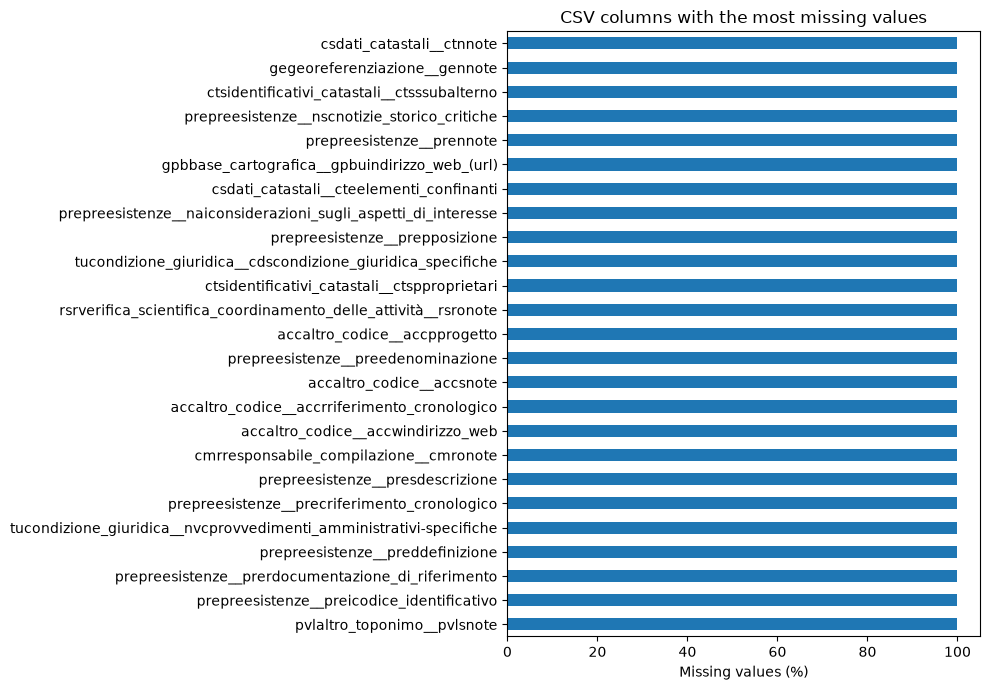

In [7]:
# Highest missing-value percentages in the CSV
csv_missing = (
    csv_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .to_frame()
)

display(csv_missing.head(25))

csv_missing.head(25).sort_values("missing_percent").plot(
    kind="barh",
    figsize=(10, 7),
    legend=False,
    title="CSV columns with the most missing values",
)
plt.xlabel("Missing values (%)")
plt.tight_layout()
plt.show()


## 3. GeoJSON inspection

In [57]:
print("Geometry type counts:")
display(geo_df["_geometry_type"].value_counts(dropna=False).rename("count").to_frame())

print("\nGeoJSON property columns:")
geo_property_columns = [
    column for column in geo_df.columns
    if not column.startswith("_")
]
display(pd.DataFrame({
    "column": geo_property_columns,
    "dtype": geo_df[geo_property_columns].dtypes.astype(str).values,
    "non_null": geo_df[geo_property_columns].notna().sum().values,
    "missing": geo_df[geo_property_columns].isna().sum().values,
}))

display(geo_df.head())


Geometry type counts:


,count
_geometry_type,
Point,44363



GeoJSON property columns:


,column,dtype,non_null,missing
0,ID,str,44363,0
1,LG,str,44363,0
2,REGIONE,int64,44363,0
3,TIPO,int64,44363,0
4,STATO_ATTU,int64,44363,0
5,L3field_2,str,44363,0


,_feature_index,_geometry_type,_coordinates,ID,LG,REGIONE,TIPO,STATO_ATTU,L3field_2
0,0,Point,"[804532.6077167223, 5110808.356105851]",ce9c9265-54dd-4779-9c4b-cc282dc908e3,,5,1,5,
1,1,Point,"[515719.62663000147, 4355316.811596198]",6e02ff7c-2b9d-40d0-a14c-e8f4d03d9a83,,19,1,5,
2,2,Point,"[1098726.0028771968, 4476786.505051931]",814d64dd-d0f5-4c01-ace8-968ec355547e,,16,1,5,
3,3,Point,"[831898.954715131, 5100476.362457695]",7aea73d3-286c-4fa1-aade-0883bd9f9c78,,5,1,5,
4,4,Point,"[888203.0546069357, 4716066.684009123]",d8d256d7-e480-40c6-bd8a-0d8d4dd66f45,,12,1,5,


In [58]:
# Coordinate validation and range
def valid_point_coordinates(value):
    return (
        isinstance(value, (list, tuple))
        and len(value) >= 2
        and all(isinstance(v, (int, float, np.number)) for v in value[:2])
        and all(np.isfinite(v) for v in value[:2])
    )

valid_coordinate_mask = geo_df["_coordinates"].map(valid_point_coordinates)

print("Features with valid numeric point coordinates:",
      f"{valid_coordinate_mask.sum():,} / {len(geo_df):,}")

if valid_coordinate_mask.any():
    coordinates = np.array(
        geo_df.loc[valid_coordinate_mask, "_coordinates"].map(lambda value: value[:2]).tolist()
    )

    coordinate_summary = pd.DataFrame({
        "axis": ["x", "y"],
        "minimum": coordinates.min(axis=0),
        "maximum": coordinates.max(axis=0),
        "mean": coordinates.mean(axis=0),
    })

    display(coordinate_summary)


Features with valid numeric point coordinates: 44,363 / 44,363


,axis,minimum,maximum,mean
0,x,3.182917e+05,1.307975e+06,7.567223e+05
1,y,4.070360e+06,5.215426e+06,4.779412e+06


## 4. ID quality checks

In [59]:
assert CSV_ID_COLUMN in csv_df.columns, (
    f"CSV ID column not found: {CSV_ID_COLUMN!r}"
)
assert GEOJSON_ID_PROPERTY in geo_df.columns, (
    f"GeoJSON ID property not found: {GEOJSON_ID_PROPERTY!r}"
)

def normalize_id(series):
    return (
        series.astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

csv_ids = normalize_id(csv_df[CSV_ID_COLUMN])
geo_ids = normalize_id(geo_df[GEOJSON_ID_PROPERTY])

id_quality = pd.DataFrame({
    "dataset": ["CSV", "GeoJSON"],
    "records": [len(csv_ids), len(geo_ids)],
    "missing_ids": [csv_ids.isna().sum(), geo_ids.isna().sum()],
    "non_missing_ids": [csv_ids.notna().sum(), geo_ids.notna().sum()],
    "unique_ids": [csv_ids.nunique(dropna=True), geo_ids.nunique(dropna=True)],
    "duplicate_rows": [
        csv_ids.duplicated(keep=False).sum(),
        geo_ids.duplicated(keep=False).sum(),
    ],
})

display(id_quality)


,dataset,records,missing_ids,non_missing_ids,unique_ids,duplicate_rows
0,CSV,44363,0,44363,44363,0
1,GeoJSON,44363,0,44363,44363,0


In [60]:
csv_duplicate_ids = (
    csv_ids.dropna()
    .value_counts()
    .loc[lambda counts: counts > 1]
    .rename("csv_count")
)

geo_duplicate_ids = (
    geo_ids.dropna()
    .value_counts()
    .loc[lambda counts: counts > 1]
    .rename("geojson_count")
)

print(f"Duplicated CSV IDs: {len(csv_duplicate_ids):,}")
display(csv_duplicate_ids.head(20).to_frame())

print(f"Duplicated GeoJSON IDs: {len(geo_duplicate_ids):,}")
display(geo_duplicate_ids.head(20).to_frame())


Duplicated CSV IDs: 0


,csv_count
id_scheda_originale,


Duplicated GeoJSON IDs: 0


,geojson_count
ID,


## 5. Compare IDs between the two files

In [61]:
csv_id_set = set(csv_ids.dropna())
geo_id_set = set(geo_ids.dropna())

only_in_csv = sorted(csv_id_set - geo_id_set)
only_in_geojson = sorted(geo_id_set - csv_id_set)
matching_ids = csv_id_set & geo_id_set
all_ids = csv_id_set | geo_id_set

comparison = pd.DataFrame({
    "metric": [
        "Unique IDs in CSV",
        "Unique IDs in GeoJSON",
        "Matching unique IDs",
        "Only in CSV",
        "Only in GeoJSON",
        "Union of unique IDs",
        "Exact set match",
    ],
    "value": [
        len(csv_id_set),
        len(geo_id_set),
        len(matching_ids),
        len(only_in_csv),
        len(only_in_geojson),
        len(all_ids),
        csv_id_set == geo_id_set,
    ],
})

display(comparison)

if csv_id_set == geo_id_set:
    print("✅ The two files contain exactly the same set of non-null IDs.")
else:
    print("❌ The ID sets do not match exactly.")


,metric,value
0,Unique IDs in CSV,44363
1,Unique IDs in GeoJSON,44363
2,Matching unique IDs,44363
3,Only in CSV,0
4,Only in GeoJSON,0
5,Union of unique IDs,44363
6,Exact set match,True


✅ The two files contain exactly the same set of non-null IDs.


In [62]:
print("Sample IDs only in CSV:")
display(pd.DataFrame({"id_only_in_csv": only_in_csv[:50]}))

print("Sample IDs only in GeoJSON:")
display(pd.DataFrame({"id_only_in_geojson": only_in_geojson[:50]}))


Sample IDs only in CSV:


,id_only_in_csv


Sample IDs only in GeoJSON:


,id_only_in_geojson


## 6. Row-level matching validation

In [63]:
csv_id_table = pd.DataFrame({
    "id": csv_ids,
    "csv_row": csv_df.index,
})

geo_id_table = pd.DataFrame({
    "id": geo_ids,
    "geojson_feature": geo_df["_feature_index"],
})

id_match_table = csv_id_table.merge(
    geo_id_table,
    on="id",
    how="outer",
    indicator=True,
)

display(id_match_table["_merge"].value_counts(dropna=False).rename("rows").to_frame())

print("\nRows not matched on both sides:")
display(
    id_match_table.loc[id_match_table["_merge"] != "both"]
    .head(100)
)


,rows
_merge,
both,44363
left_only,0
right_only,0



Rows not matched on both sides:


,id,csv_row,geojson_feature,_merge


## 7. Final validation summary

In [64]:
checks = {
    "same_number_of_records": len(csv_df) == len(geo_df),
    "csv_has_no_missing_ids": csv_ids.isna().sum() == 0,
    "geojson_has_no_missing_ids": geo_ids.isna().sum() == 0,
    "csv_ids_are_unique": csv_ids.dropna().is_unique,
    "geojson_ids_are_unique": geo_ids.dropna().is_unique,
    "id_sets_match_exactly": csv_id_set == geo_id_set,
}

final_summary = pd.DataFrame({
    "check": checks.keys(),
    "passed": checks.values(),
})

display(final_summary)

if final_summary["passed"].all():
    print("✅ All checks passed: the files have one-to-one matching IDs.")
else:
    print("⚠️ One or more checks failed. Review the sections above.")


,check,passed
0,same_number_of_records,True
1,csv_has_no_missing_ids,True
2,geojson_has_no_missing_ids,True
3,csv_ids_are_unique,True
4,geojson_ids_are_unique,True
5,id_sets_match_exactly,True


✅ All checks passed: the files have one-to-one matching IDs.


In [65]:
# Dataset dimensions
number_of_rows, number_of_columns = csv_df.shape

# A "data point" can mean every cell or only populated cells
total_cells = csv_df.size
populated_cells = csv_df.notna().sum().sum()
missing_cells = csv_df.isna().sum().sum()

print(f"Rows:                 {number_of_rows:,}")
print(f"Columns:              {number_of_columns:,}")
print(f"Total cells:          {total_cells:,}")
print(f"Populated cells:      {populated_cells:,}")
print(f"Missing cells:        {missing_cells:,}")
print(f"Completeness:         {populated_cells / total_cells:.1%}")

Rows:                 44,363
Columns:              26
Total cells:          1,153,438
Populated cells:      1,111,393
Missing cells:        42,045
Completeness:         96.4%


In [66]:
all_columns = csv_df.columns.tolist()

print(f"Number of columns: {len(all_columns)}")

for position, column in enumerate(all_columns, start=1):
    print(f"{position:3}. {column}")

Number of columns: 26
  1. id_scheda_originale
  2. numero_catalogo_iccd
  3. categoria_edificio
  4. tipologia_edificio
  5. numero_spazi
  6. regione
  7. sigla_provincia
  8. comune
  9. contesto_paesaggistico
 10. tipo_dissesto_idrogeologico
 11. livello_rischio_frana
 12. livello_rischio_alluvione
 13. livello_rischio_valanga
 14. tipo_abitazione_rurale
 15. periodo_cronologico
 16. stato_conservazione
 17. data_documento
 18. anno_cartografia_igm
 19. riferimento_bibliografico
 20. anno_compilazione_scheda
 21. nome_compilatore
 22. ente_compilatore
 23. nome_responsabile_scientifico
 24. ruolo_responsabile_scientifico
 25. ente_responsabile_scientifico
 26. profilo_pubblicazione


In [67]:
EXPECTED_ROWS = 44_363
MINIMUM_COMPLETENESS = 0.60

# Confirm the source row count
rows_before = len(csv_df)

assert rows_before == EXPECTED_ROWS, (
    f"Expected {EXPECTED_ROWS:,} input rows, "
    f"but found {rows_before:,}."
)

# Treat empty and whitespace-only strings as missing
cleaned_df = csv_df.replace(r"^\s*$", pd.NA, regex=True)

# Calculate the proportion of populated values in every column
column_completeness = cleaned_df.notna().mean()

# Keep columns containing at least 60% populated data
columns_to_keep = column_completeness[
    column_completeness >= MINIMUM_COMPLETENESS
].index.tolist()

columns_removed = column_completeness[
    column_completeness < MINIMUM_COMPLETENESS
].index.tolist()

filtered_df = cleaned_df.loc[:, columns_to_keep].copy()

# Verify that filtering columns did not change the rows
rows_after = len(filtered_df)

assert rows_after == rows_before == EXPECTED_ROWS, (
    f"Row-count check failed: before={rows_before:,}, "
    f"after={rows_after:,}, expected={EXPECTED_ROWS:,}."
)

print(f"Rows before:      {rows_before:,}")
print(f"Rows after:       {rows_after:,}")
print(f"Columns before:   {csv_df.shape[1]:,}")
print(f"Columns after:    {filtered_df.shape[1]:,}")
print(f"Columns removed:  {len(columns_removed):,}")
print("✅ Row count remains exactly 44,363.")


Rows before:      44,363
Rows after:       44,363
Columns before:   26
Columns after:    26
Columns removed:  0
✅ Row count remains exactly 44,363.


In [68]:
display(filtered_df.head())
print(filtered_df.columns.tolist())

,id_scheda_originale,numero_catalogo_iccd,categoria_edificio,tipologia_edificio,numero_spazi,regione,sigla_provincia,comune,contesto_paesaggistico,tipo_dissesto_idrogeologico,livello_rischio_frana,livello_rischio_alluvione,livello_rischio_valanga,tipo_abitazione_rurale,periodo_cronologico,stato_conservazione,data_documento,anno_cartografia_igm,riferimento_bibliografico,anno_compilazione_scheda,nome_compilatore,ente_compilatore,nome_responsabile_scientifico,ruolo_responsabile_scientifico,ente_responsabile_scientifico,profilo_pubblicazione
0,ce9c9265-54dd-4779-9c4b-cc282dc908e3,182407.0,EDIFICIO SINGOLO,casa con loggiato,nr,Friuli-Venezia Giulia,UD,Dignano,pianura,alluvione,nessun rischio,molto elevato,elevato,casa colonica,XVIII-XX,mediocre,2024,1959,"Petriccione, Livio [et al.] Architettura, tradizione e recupero in un centro storico minore del Friuli-Venezia Giuli...",2024.0,"Rulli, Eduardo",Atlante Group SPA,"Parisi, Valeria",responsabile coordinamento delle attività,Atlante Group s.r.l.,2.0
1,6e02ff7c-2b9d-40d0-a14c-e8f4d03d9a83,252733.0,EDIFICIO SINGOLO,casa a corte chiusa,nr,Sardegna,SU,Soleminis,collina,nessun dissesto evidente,nessun rischio,nessun rischio,nessun rischio,casa contadina,XIX,buono,2025,1846,"O. Baldacci, La casa rurale in Sardegna, Centro di Studi per la Geografia Etnologica, Firenze, 1952",2025.0,"Camatti, Matteo",Progetto PSC,"cesarano, barbara",responsabile coordinamento delle attività,progetto psc,1.0
2,814d64dd-d0f5-4c01-ace8-968ec355547e,223849.0,EDIFICIO CON ANNESSI,casa a scala esterna,1,Basilicata,PZ,San Martino d'Agri,altopiano,nessun dissesto evidente,nessun rischio,nessun rischio,nessun rischio,casa padronale,XIX-XX,mediocre,2024,1956,"Franciosa Luchino, “La casa rurale nella Lucania”, con una prefazione di Renato Biasutti, C.N.R., “Ricerche sulle di...",2024.0,"Trausi, Pier Pasquale",GLOSSA Srl,"maddaluno, corrado",responsabile coordinamento delle attività,GLOSSA Srl,2.0
3,7aea73d3-286c-4fa1-aade-0883bd9f9c78,182399.0,EDIFICIO CON ANNESSI,cascina,2,Friuli-Venezia Giulia,UD,Comune di Pavia di Udine,pianura,alluvione,nessun rischio,medio,nessun rischio,casa padronale,XVIII-XIX,buono,2024,1960,"Pagano Giuseppe - Daniel Guarniero, Architettura rurale\nitaliana, in Quaderni della Triennale, Milano, Hulrico Hoep...",2024.0,"Rulli, Eduardo",Atlante Group SPA,"Parisi, Valeria",responsabile coordinamento delle attività,Atlante Group s.r.l.,2.0
4,d8d256d7-e480-40c6-bd8a-0d8d4dd66f45,310548.0,COMPLESSO,casa a edifici affiancati,2,Abruzzo,TE,Castelli,collina,nessun dissesto evidente,nessun rischio,nessun rischio,nessun rischio,non rilevabile,XIX,pessimo,2025/03/25,1955,"Barbieri G., Gambi L., (a cura di), La casa rurale in Italia, Firenze, Olschki, 1970.",2025.0,"Frezzini, Luca",Unimol,"Alessandria, Francesco",responsabile coordinamento delle attività,Cles,2.0


['id_scheda_originale', 'numero_catalogo_iccd', 'categoria_edificio', 'tipologia_edificio', 'numero_spazi', 'regione', 'sigla_provincia', 'comune', 'contesto_paesaggistico', 'tipo_dissesto_idrogeologico', 'livello_rischio_frana', 'livello_rischio_alluvione', 'livello_rischio_valanga', 'tipo_abitazione_rurale', 'periodo_cronologico', 'stato_conservazione', 'data_documento', 'anno_cartografia_igm', 'riferimento_bibliografico', 'anno_compilazione_scheda', 'nome_compilatore', 'ente_compilatore', 'nome_responsabile_scientifico', 'ruolo_responsabile_scientifico', 'ente_responsabile_scientifico', 'profilo_pubblicazione']


In [69]:
columns_to_remove_manually = [
    "ente_responsabile_scientifico",
    "ruolo_responsabile_scientifico",
    "anno_compilazione_scheda"
]

# Check for misspelled or unavailable names
columns_not_found = [
    column for column in columns_to_remove_manually
    if column not in filtered_df.columns
]

if columns_not_found:
    print("⚠️ These columns were not found:")
    for column in columns_not_found:
        print(f"  - {column}")

# Remove every valid requested column
valid_columns_to_remove = [
    column for column in columns_to_remove_manually
    if column in filtered_df.columns
]

final_df = filtered_df.drop(
    columns=valid_columns_to_remove
).copy()

# Removing columns must not affect the number of rows
assert len(final_df) == 44_363, (
    f"Expected 44,363 rows, but found {len(final_df):,}."
)

print(f"Manually removed: {len(valid_columns_to_remove):,} columns")
print(f"Remaining columns: {final_df.shape[1]:,}")
print(f"Remaining rows: {len(final_df):,}")
print("✅ Row count remains exactly 44,363.")

display(final_df.head())

Manually removed: 3 columns
Remaining columns: 23
Remaining rows: 44,363
✅ Row count remains exactly 44,363.


,id_scheda_originale,numero_catalogo_iccd,categoria_edificio,tipologia_edificio,numero_spazi,regione,sigla_provincia,comune,contesto_paesaggistico,tipo_dissesto_idrogeologico,livello_rischio_frana,livello_rischio_alluvione,livello_rischio_valanga,tipo_abitazione_rurale,periodo_cronologico,stato_conservazione,data_documento,anno_cartografia_igm,riferimento_bibliografico,nome_compilatore,ente_compilatore,nome_responsabile_scientifico,profilo_pubblicazione
0,ce9c9265-54dd-4779-9c4b-cc282dc908e3,182407.0,EDIFICIO SINGOLO,casa con loggiato,nr,Friuli-Venezia Giulia,UD,Dignano,pianura,alluvione,nessun rischio,molto elevato,elevato,casa colonica,XVIII-XX,mediocre,2024,1959,"Petriccione, Livio [et al.] Architettura, tradizione e recupero in un centro storico minore del Friuli-Venezia Giuli...","Rulli, Eduardo",Atlante Group SPA,"Parisi, Valeria",2.0
1,6e02ff7c-2b9d-40d0-a14c-e8f4d03d9a83,252733.0,EDIFICIO SINGOLO,casa a corte chiusa,nr,Sardegna,SU,Soleminis,collina,nessun dissesto evidente,nessun rischio,nessun rischio,nessun rischio,casa contadina,XIX,buono,2025,1846,"O. Baldacci, La casa rurale in Sardegna, Centro di Studi per la Geografia Etnologica, Firenze, 1952","Camatti, Matteo",Progetto PSC,"cesarano, barbara",1.0
2,814d64dd-d0f5-4c01-ace8-968ec355547e,223849.0,EDIFICIO CON ANNESSI,casa a scala esterna,1,Basilicata,PZ,San Martino d'Agri,altopiano,nessun dissesto evidente,nessun rischio,nessun rischio,nessun rischio,casa padronale,XIX-XX,mediocre,2024,1956,"Franciosa Luchino, “La casa rurale nella Lucania”, con una prefazione di Renato Biasutti, C.N.R., “Ricerche sulle di...","Trausi, Pier Pasquale",GLOSSA Srl,"maddaluno, corrado",2.0
3,7aea73d3-286c-4fa1-aade-0883bd9f9c78,182399.0,EDIFICIO CON ANNESSI,cascina,2,Friuli-Venezia Giulia,UD,Comune di Pavia di Udine,pianura,alluvione,nessun rischio,medio,nessun rischio,casa padronale,XVIII-XIX,buono,2024,1960,"Pagano Giuseppe - Daniel Guarniero, Architettura rurale\nitaliana, in Quaderni della Triennale, Milano, Hulrico Hoep...","Rulli, Eduardo",Atlante Group SPA,"Parisi, Valeria",2.0
4,d8d256d7-e480-40c6-bd8a-0d8d4dd66f45,310548.0,COMPLESSO,casa a edifici affiancati,2,Abruzzo,TE,Castelli,collina,nessun dissesto evidente,nessun rischio,nessun rischio,nessun rischio,non rilevabile,XIX,pessimo,2025/03/25,1955,"Barbieri G., Gambi L., (a cura di), La casa rurale in Italia, Firenze, Olschki, 1970.","Frezzini, Luca",Unimol,"Alessandria, Francesco",2.0


In [70]:
PERCORSO_OUTPUT = CSV_PATH.with_name(
    "dati_schede_min_rinominato.csv"
)

df_rinominato.to_csv(
    PERCORSO_OUTPUT,
    index=False,
    encoding="utf-8",
)

print(f"File salvato: {PERCORSO_OUTPUT.resolve()}")
print(f"Dimensioni finali: {df_rinominato.shape}")

File salvato: /mnt/c/Users/gazza/Documents/DOTDOTDOT - summer/FINAL_map/rurale_map_poc/online_map/data/dati_schede_min_rinominato.csv
Dimensioni finali: (44363, 26)
